Exploring the titanic

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [ ]:
#Total survivors
Total_survivors= df['Survived'].sum()
print('Total number of survivors:', Total_survivors)
Dead = (df['Survived']==0).sum()
print('Dead:', Dead)

Total number of survivors: 342
Dead: 549


In [36]:
#Reassigning Survival from 0 &1
df['Survival_Status'] =df['Survived'].map({0: 'Dead', 1: 'Alive'})
print(df[['Survived', 'Survival_Status']].head())

   Survived Survival_Status
0         0            Dead
1         1           Alive
2         1           Alive
3         1           Alive
4         0            Dead


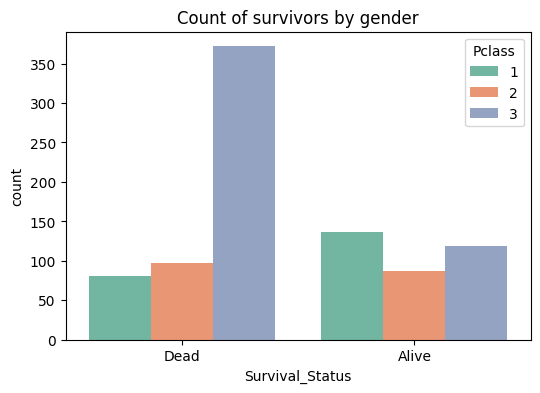

In [15]:
# Survival based on gender
plt.figure(figsize=(6,4))
sns.countplot(x='Survival_Status', hue='Pclass', data=df, palette='Set2')
plt.title('Count of survivors by gender')
plt.show()


In [17]:
Average_age = df['Age'].mean()
Average_fare= df['Fare'].mean()
print('Average Age: ', Average_age)
print('Average Fare: ', Average_fare)

Average Age:  29.69911764705882
Average Fare:  32.204207968574636


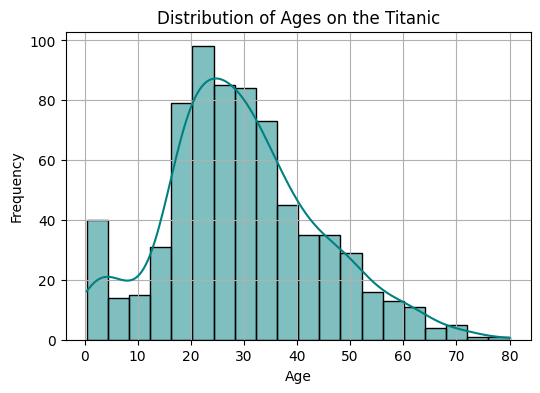

In [19]:
plt.figure(figsize=(6,4))
sns.histplot(df['Age'], kde=True, color='teal')
plt.title('Distribution of Ages on the Titanic')
plt.grid()
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

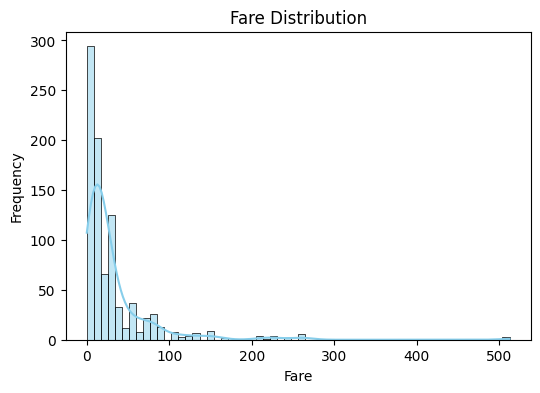

In [21]:
plt.figure(figsize=(6,4))
sns.histplot(df['Fare'], kde=True, color='skyblue')
plt.title('Fare Distribution')
plt.xlabel('Fare')
plt.ylabel('Frequency')
plt.show()

<Figure size 600x400 with 0 Axes>

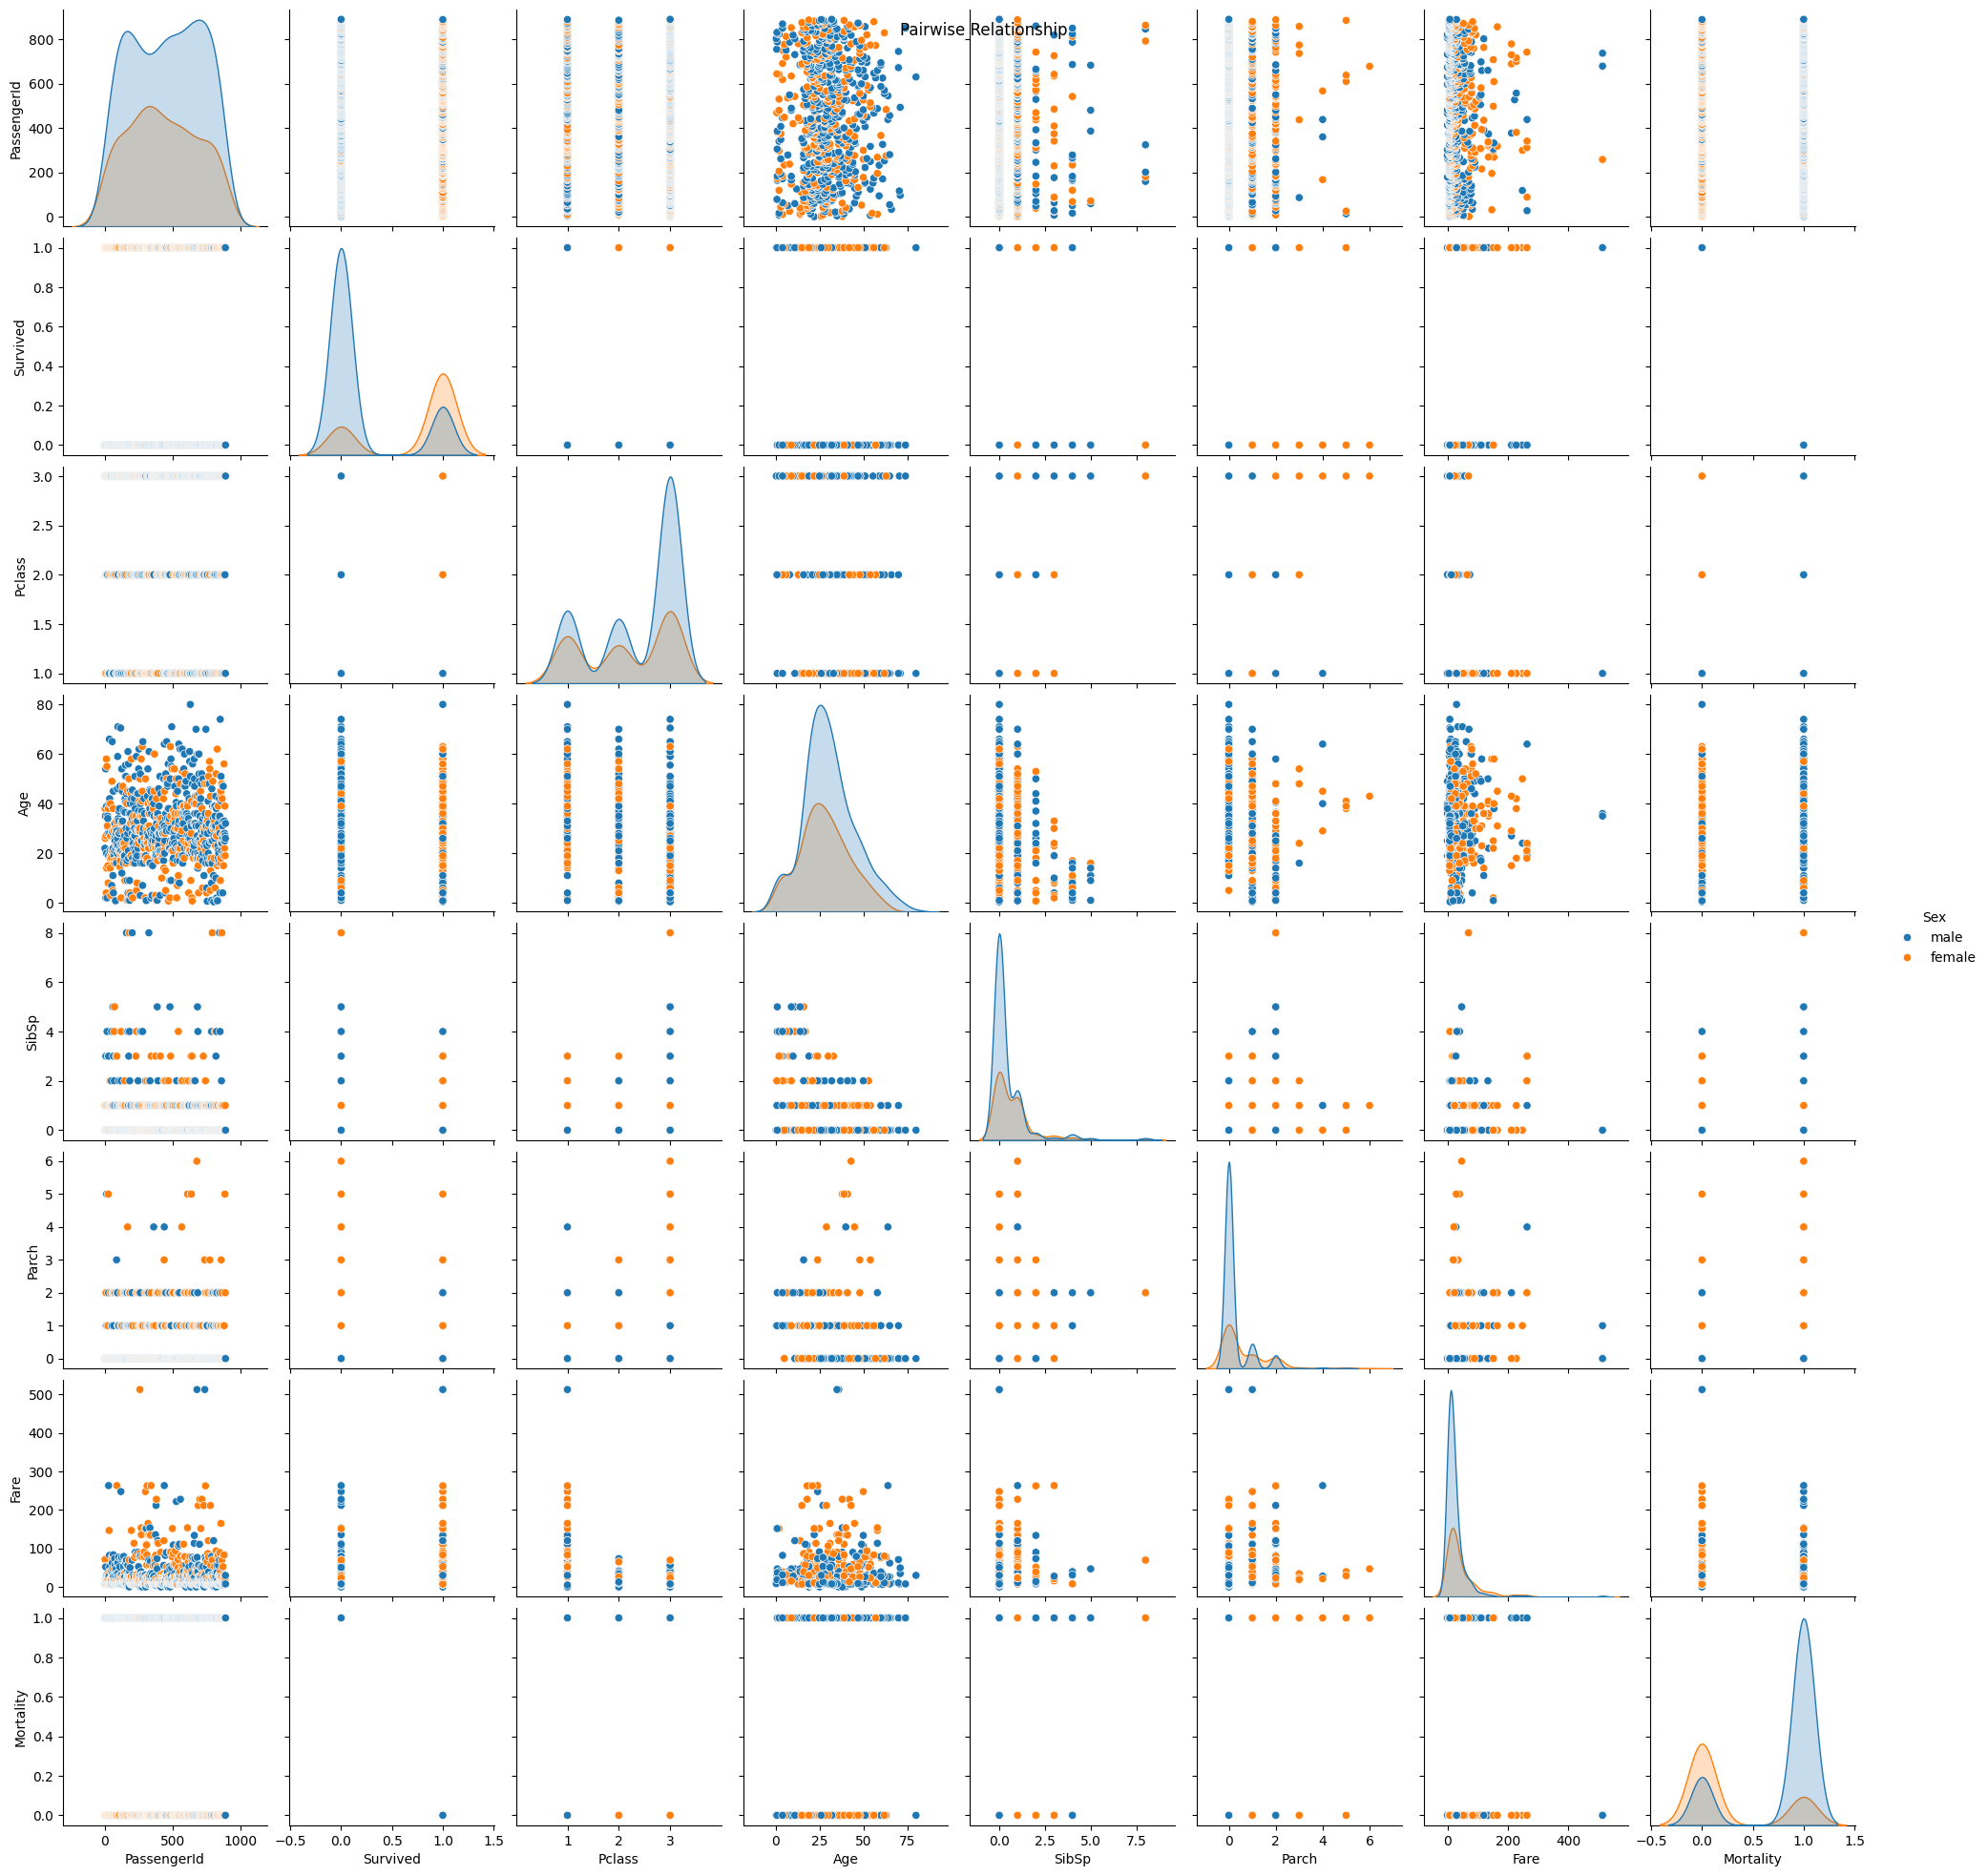

In [22]:
plt.figure(figsize=(6,4))
sns.pairplot(df, hue='Sex',diag_kind = 'kde')
plt.suptitle('Pairwise Relationship')
plt.show()

In [25]:
numeric_df = df.select_dtypes(include='number')
numeric_df.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Mortality
0,1,0,3,22.0,1,0,7.2500,1
1,2,1,1,38.0,1,0,71.2833,0
2,3,1,3,26.0,0,0,7.9250,0
3,4,1,1,35.0,1,0,53.1000,0
4,5,0,3,35.0,0,0,8.0500,1


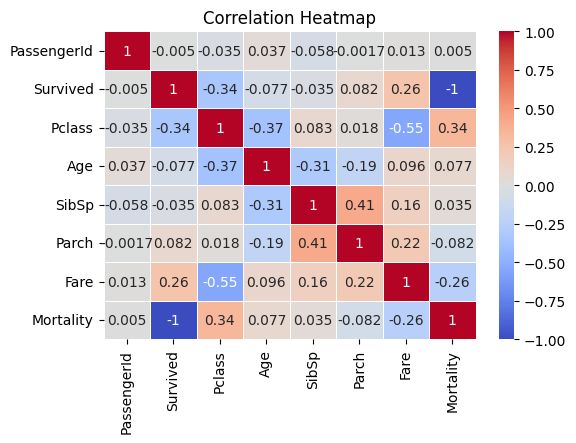

In [26]:
corr = numeric_df.corr(numeric_only=True)
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

In [29]:
df['Age'].max()


np.float64(80.0)

In [31]:
df['Age'].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

In [45]:
Age_groups = pd.DataFrame({
    'forty_fifty': (df['Age']>40) & (df['Age']<50),
    'fifty_sixty': (df['Age'] > 50) & (df['Age'] < 60),
    'sixty_seventy': (df['Age'] > 60) & (df['Age'] < 70),
    'seventy_eighty': (df['Age'] > 70) & (df['Age'] < 80),
    'thirty_forty': (df['Age'] > 30) & (df['Age'] < 40),
    'twenty_thirty': (df['Age'] > 20) & (df['Age'] < 30)
})
print(type(Age_groups))

<class 'pandas.DataFrame'>


In [48]:
df['Age_groups'] = pd.cut(df['Age'], 
                          bins=[20,30,40,50,60,70,80], 
                          labels=['20-30','30-40','40-50','50-60','60-70','70-80'])

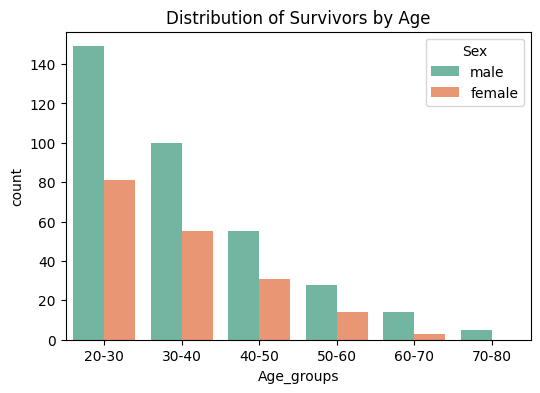

In [50]:
# Countplot
plt.figure(figsize=(6,4))
sns.countplot(x='Age_groups', data= df, hue='Sex', palette='Set2')
plt.title('Distribution of Survivors by Age')
plt.show()

In [52]:
# Calculate mean survival rate per age group
survival_rates = df.groupby('Age_groups')['Survived'].mean() * 100
print(survival_rates)

Age_groups
20-30    36.521739
30-40    44.516129
40-50    38.372093
50-60    40.476190
60-70    23.529412
70-80    20.000000
Name: Survived, dtype: float64


C:\Users\user\AppData\Local\Temp\ipykernel_22276\3720888436.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=survival_rates.index, y=survival_rates.values, palette='Set2')


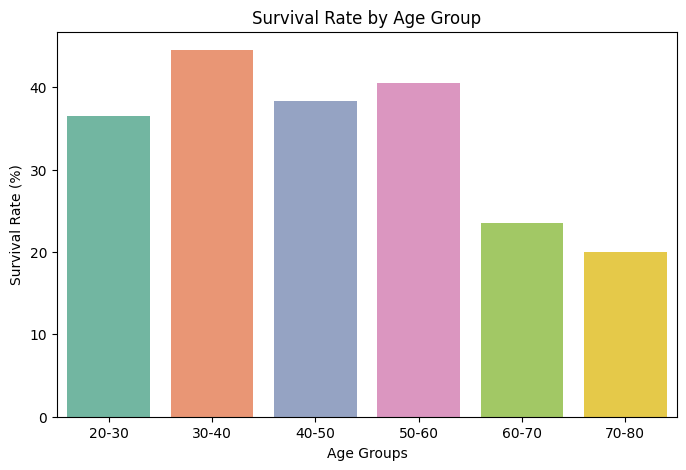

In [53]:
plt.figure(figsize=(8,5))
sns.barplot(x=survival_rates.index, y=survival_rates.values, palette='Set2')
plt.ylabel('Survival Rate (%)')
plt.xlabel('Age Groups')
plt.title('Survival Rate by Age Group')
plt.show()